## **1. Préliminaires**

### **1.1. Contexte**
Nous pratiquons dans ce notebook l'analyse de données sur les données provenant d'un dataset `heart attack prediction` de [Kaggle](https://kaggle.com/datasets).
Nous allons dans ce notebook explorer , visualiser et interpreter nos variables.

### **1.2. Imports des librairies**

Dans cette section nous allons importer les librairies principales .

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **1.3. Chargement des données**
Nous allons maintenant charger notre dataset .

In [2]:
# chargement du dataset
data = pd.read_csv('../data/data-cleaned.csv')

# affichage d'un extrait
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,0
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,0
2,29,1,2,140.0,243.0,0.0,0.0,170.0,0.0,0.0,0
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,0
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,0


### **1.4. Structure et typologie des données**
Nous allons analyser la structure de notre jeu de données et le types des données et changer les types de données si nécessaires.

In [3]:
# dimension du dataset
data.shape

(284, 11)

In [4]:
# affichage des infos sur les variables et leurs types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284 entries, 0 to 283
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       284 non-null    int64  
 1   sex       284 non-null    int64  
 2   cp        284 non-null    int64  
 3   trestbps  284 non-null    float64
 4   chol      284 non-null    float64
 5   fbs       284 non-null    float64
 6   restecg   284 non-null    float64
 7   thalach   284 non-null    float64
 8   exang     284 non-null    float64
 9   oldpeak   284 non-null    float64
 10  num       284 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 24.5 KB


## **2. Analyse Exploratoire des données**

### **2.1. Analyse univariée**

Nous allons observer la distribution de chaque variable

Nous allons créer quelques fonctions

In [ ]:
# fonction retournant des pie charts


def show_pie_charts(params: dict):
    nrows = int(len(params) / 2)
    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(30, 20))
    axes_plats = axes.flatten()
    for i, (col, param) in enumerate(params.items()):
        axes_plats[i].pie(
            x=param["count"],
            labels=param[col],
            startangle=90,
            colors=param["color"],
            autopct="%.2f%%",
        )
        axes_plats[i].legend()
        axes_plats[i].set_title(f"Repartition des partiens par {col}")
    if len(params)<len(axes_plats):
        for j in range(len(params),len(axes_plats)):
            axes_plats[j].set_axis_off()

In [174]:
# fonction retournant des bar charts
import math
def show_bar_charts(params: dict):
    nrows = math.ceil(len(params) / 2)
    fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(30, 20))
    axes_plats = axes.flatten()
    for i, (col, param) in enumerate(params.items()):
        ax=axes_plats[i]
        sns.barplot(ax=ax,data=param['value'],hue=col,y='count',errorbar=None,palette=param.get('palette'))
        ax.set_ylabel("nombre de patients")
        ax.set_xlabel(col)
        ax.set_title(f"Diagramme à barre de repartition par {col}")
        if param.get('yticks') is not None:
            ax.set_yticks(ticks=param.get('yticks'))
    if len(params)<len(axes_plats):
        for j in range(len(params),len(axes_plats)):
            axes_plats[j].set_axis_off()

La variable `num`

In [131]:
# le compte des modalités de nums
num = data["num"].value_counts().reset_index()

# les labels
num_labels = {0: "malade", 1: "sain"}
num.replace({"num": num_labels}, inplace=True)

# les couleurs
num["color"] = sns.color_palette(palette="viridis", n_colors=num.shape[0])

La variable `fbs`

In [132]:
# compte des modalités de fbs
fbs = data.value_counts(subset=['fbs']).reset_index()

# les labels
fbs_labels = {0: "Normal", 1: "Hyperglycémie"}
fbs.replace({'fbs':fbs_labels},inplace=True)

# les couleurs
fbs['color'] = sns.color_palette(palette='pastel',n_colors=fbs.shape[0])

La variable `restecg`

In [133]:
# le compte des modalités de restecg
restecg = data.value_counts(subset=['restecg']).reset_index()

# les labels
restecg_labels={0:'Normal',1:'Anomalie des ondes ST-T',2:'Hypertrophie ventriculaire gauche probable ou certaine'}
restecg.replace({'restecg':restecg_labels},inplace=True)

# les couleurs
restecg['color'] = sns.color_palette(palette="husl", n_colors=restecg.shape[0])

La variable `exang`

In [134]:
# le compte des modalités de exang
exang = data.value_counts(subset=["exang"]).reset_index()

# les labels
exang_labels = {
    0: "Normal",
    1: "Angine induite par l’exercice",
}
exang.replace({"exang": exang_labels}, inplace=True)

# les couleurs
exang["color"] = sns.color_palette(palette="magma", n_colors=exang.shape[0])

In [135]:
pie_chart_params={
    'restecg':restecg,
    'fbs':fbs,
    'num':num,
    'exang':exang
}

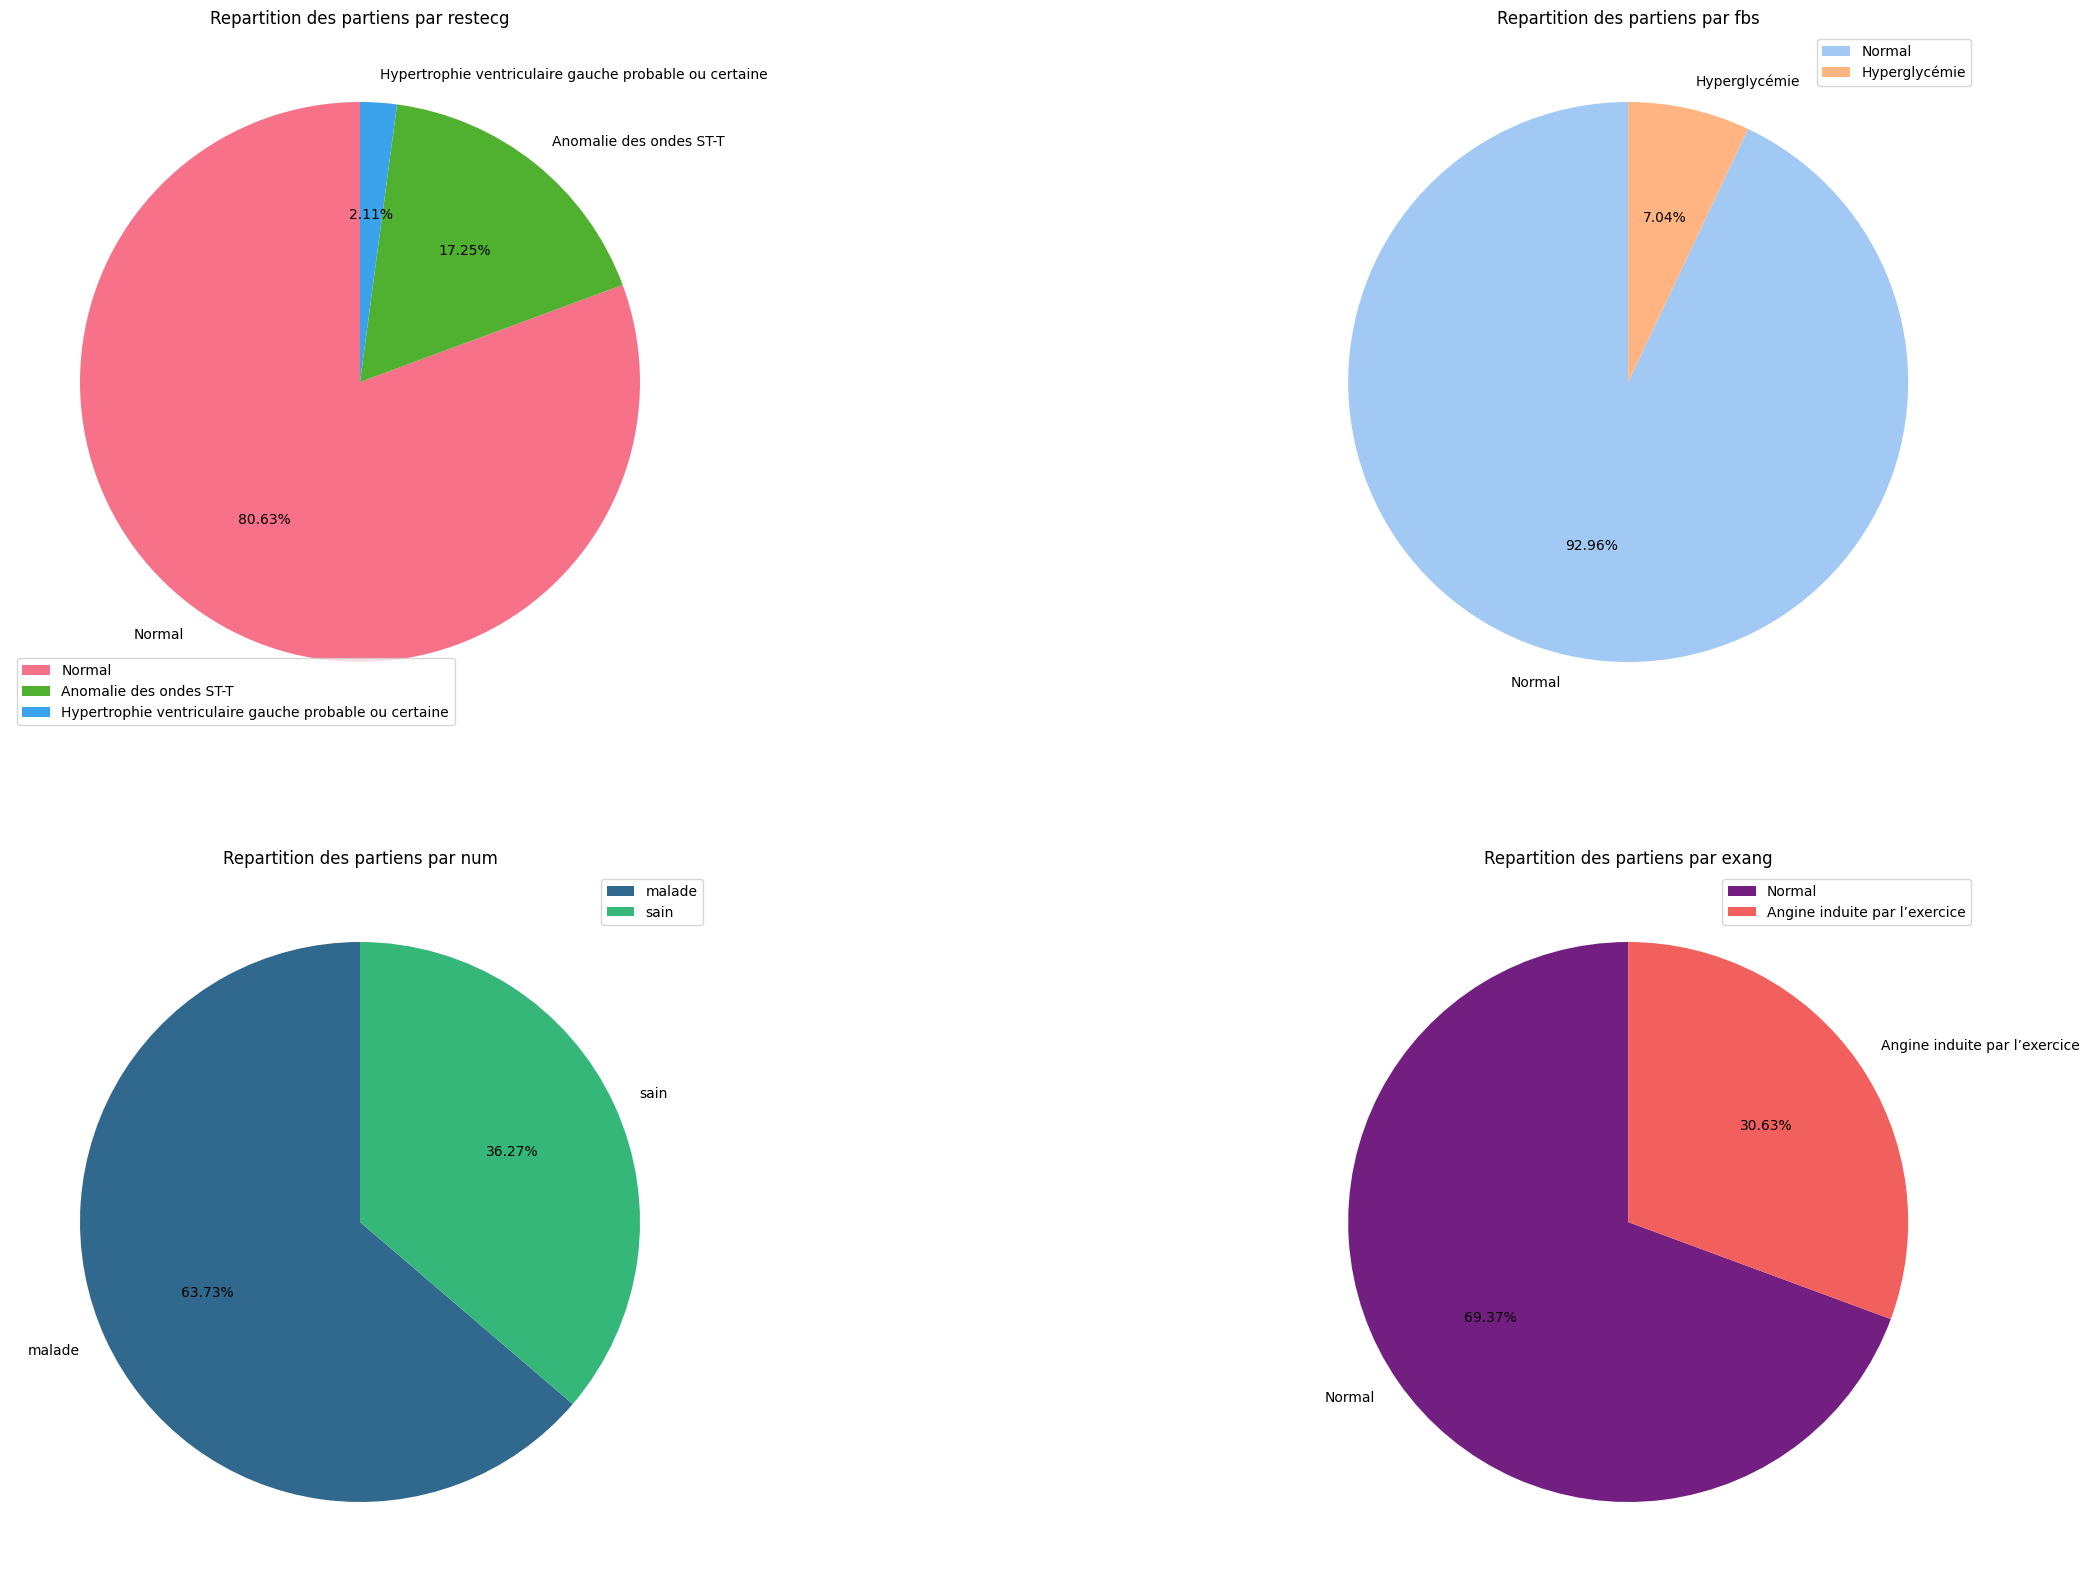

In [136]:
pie_charts=show_pie_charts(params=pie_chart_params)
plt.show()

**interpretation**  : 

- `restecg` : On remarque qu'il y a une minorité (7.04%) de patients qui présentent une hyperglycémie.

- `num` : Notre dataset est majoritairement composé de patients malades.


La variable `age`

In [137]:
# discretisation de la variable âge
age_bins = pd.cut(data["age"], bins=np.arange(20, 80, 10)).value_counts().reset_index()

age = {"value": age_bins, "palette": None, "yticks": np.arange(0, 140, 10)}

La variabe `cp`

In [138]:
# le compte par modalité
cp_counts = data["cp"].value_counts().reset_index()
# labelisation
labels = {
    1: "Angine typique",
    2: "Angine atypique",
    3: "Douleur non angineuse",
    4: "Asymptomatique",
}
cp_counts.replace({"cp": labels}, inplace=True)

cp = {"value": cp_counts, "yticks": np.arange(0, 140, 10),"palette":"plasma"}

La variable `thalach`

In [139]:
# discretisation de la variable
thalach_bins = (
    pd.cut(data["thalach"], bins=np.arange(80, 220, 20)).value_counts().reset_index()
)

thalach = {"value": thalach_bins,'yticks':None,'palette':'flare'}

In [172]:
bar_charts_params={
    'cp':cp,
    'thalach':thalach,
    'age':age
}

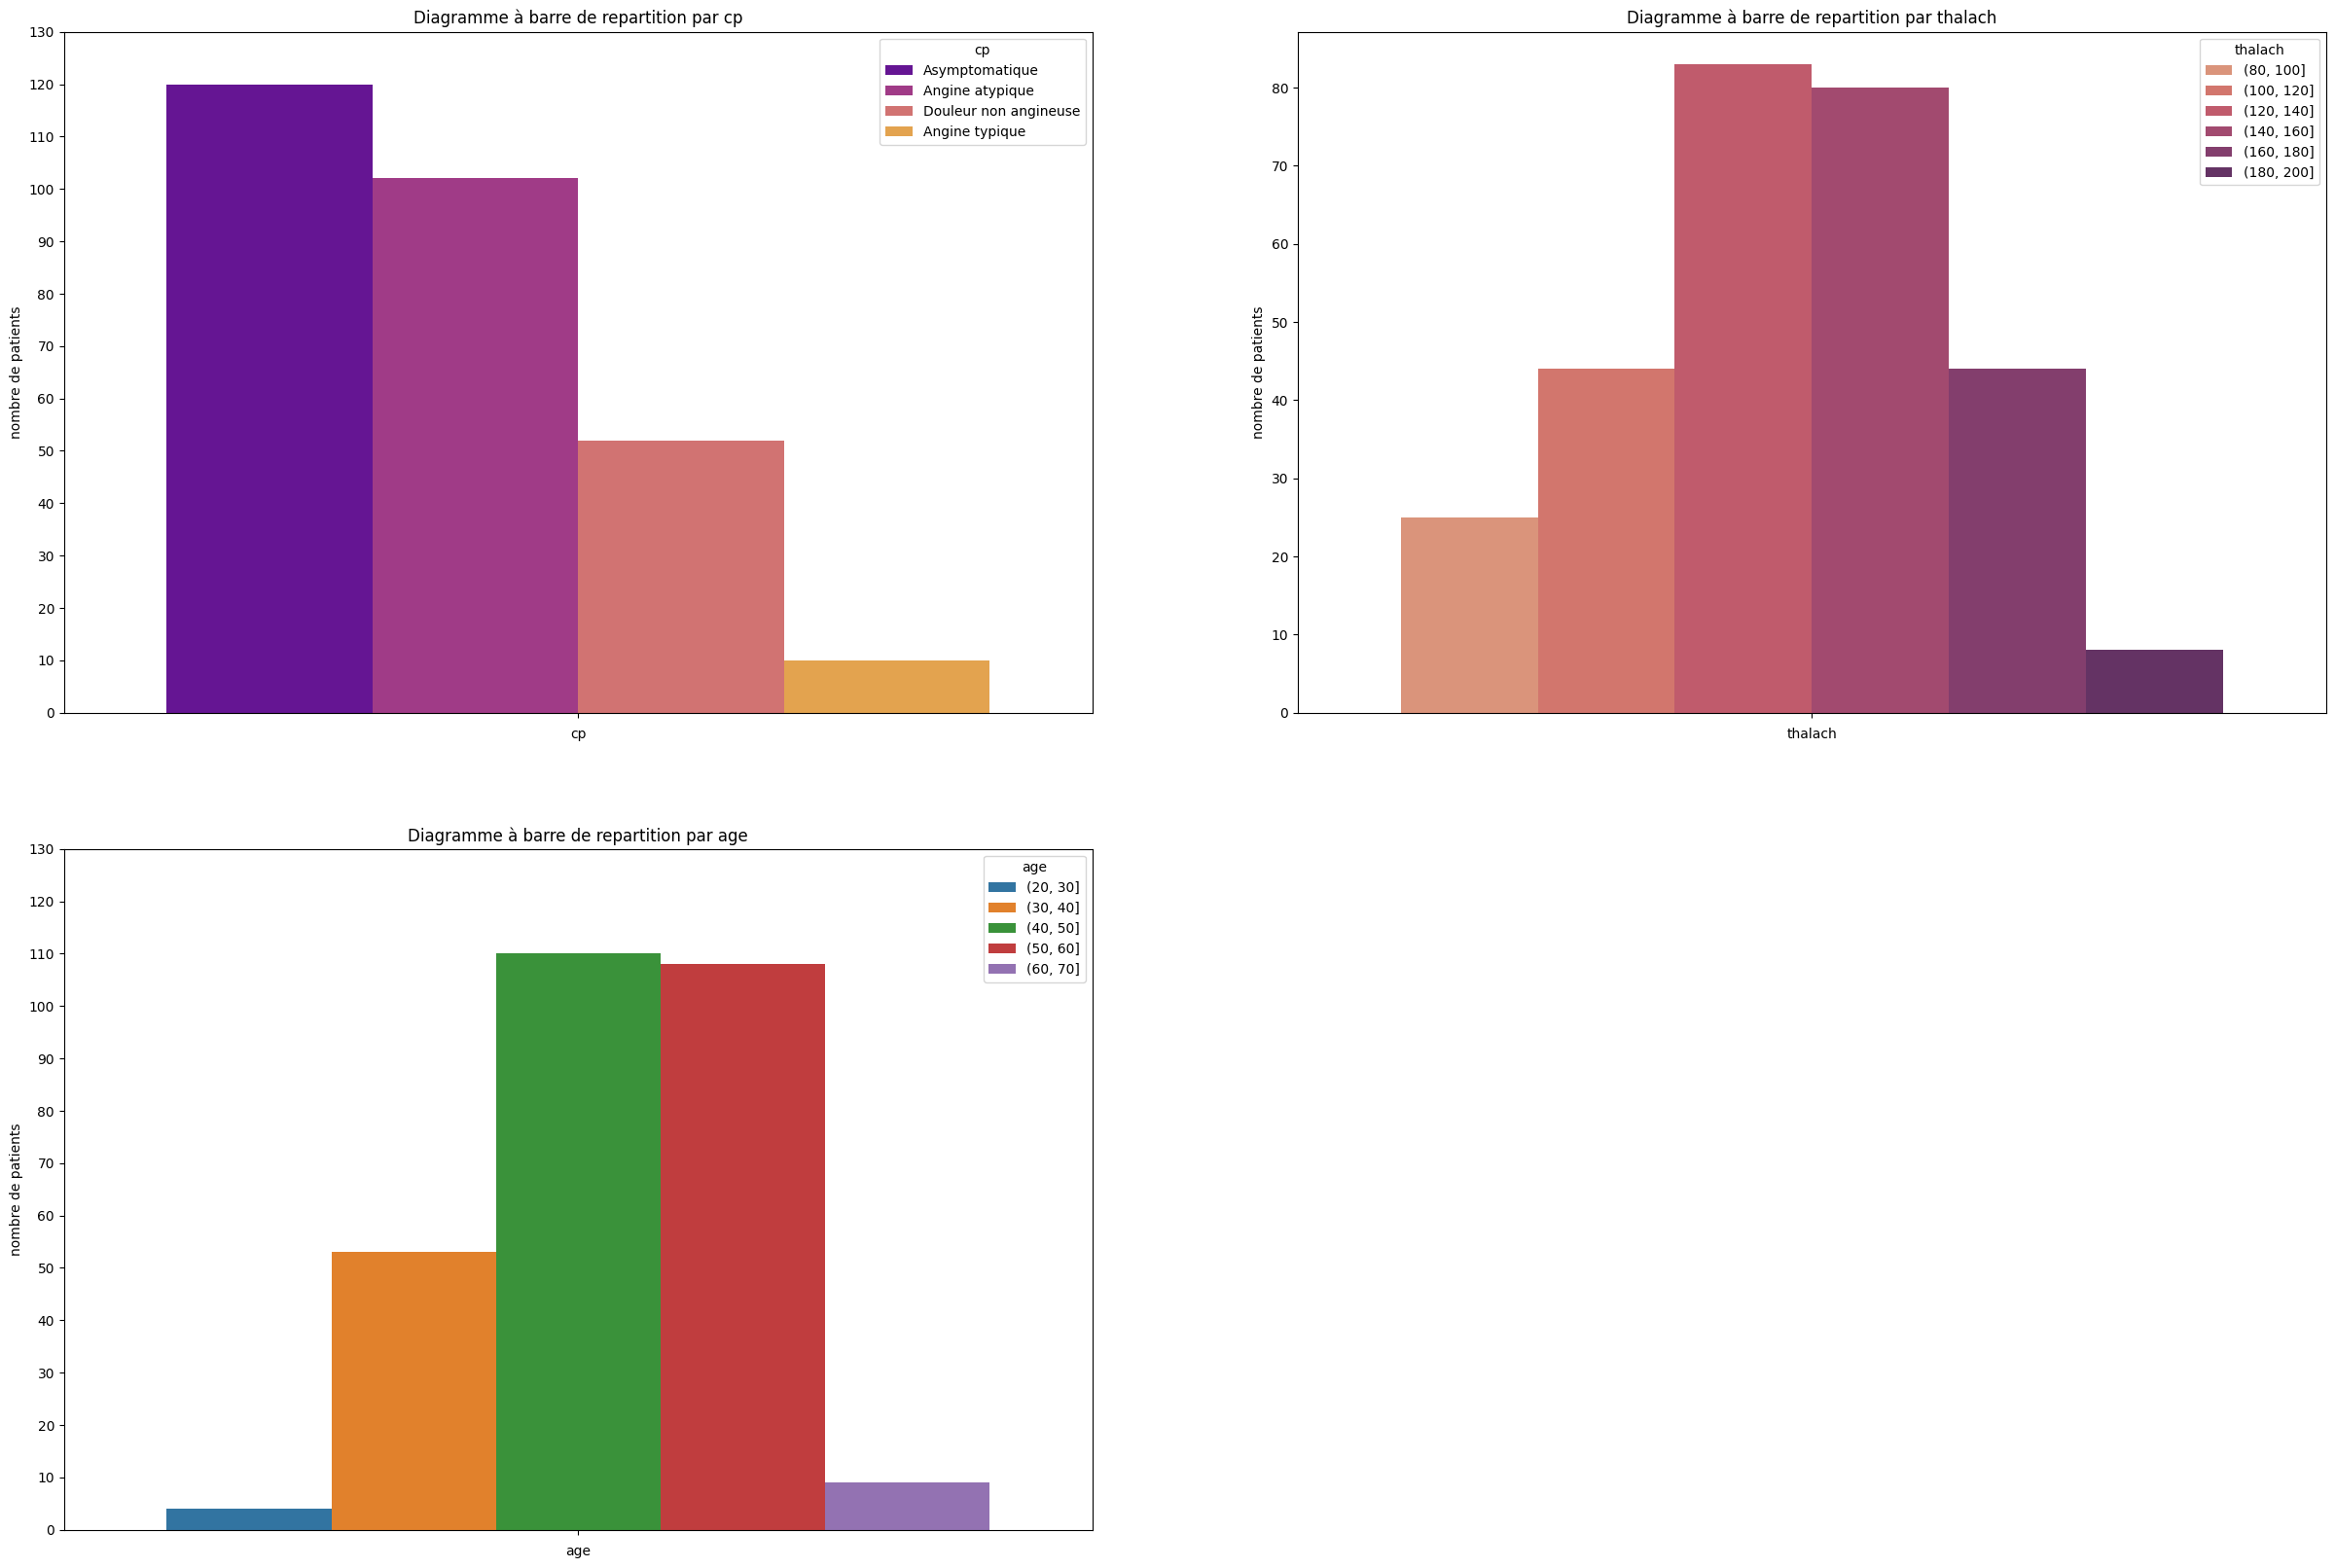

In [175]:
bar_charts = show_bar_charts(params=bar_charts_params)
plt.show()

**Interprétation age** 

On remarque que la majorité des patients sont dans la tranche  entre 40 et 60 ans avec une minorité pour les tranche 20 à 30 et 60 à 70.

**interprétation cp** : 

On remarque que le cas `asymptomatique` est majoritaire suivi par les indidividus du cas `Angine atypique` .

Le cas `Anginge typique` reste le plus sous représentée suivi du cas `Douleur non angineuse`.